<a href="https://colab.research.google.com/github/akshatkeshri/D2C-Churn-Part1-EDA/blob/main/D2C_Churn_Part1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# cell 1
!pip install gdown -q
import gdown
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

folder_url = 'https://drive.google.com/drive/folders/1PmLapJI1VSDgvl_AxARNKwM1MCd3WFX0'
output_dir = './data'

if not os.path.exists(output_dir):
    print("Fetching dataset from Google Drive...")

    !gdown --folder {folder_url} -O {output_dir}
    print(" Download complete!")
else:
    print(" Data folder already exists.")

print("\nFiles in the data directory:")
print(os.listdir(output_dir))

 Data folder already exists.

Files in the data directory:
['DATA_DICTIONARY.md', 'support_tickets.csv', 'STUDENT_FACING_PROBLEM_STATEMENT.md', 'orders.csv', 'web_events_snapshot.csv', 'customers.csv', 'rfm_modeling_snapshot.csv', 'churn_labels.csv', 'intervention_history.csv']


In [13]:
# Cell 2
snapshot_date = pd.to_datetime('2025-09-30')

print("--- Schema Inspection ---")
print("Orders columns:", orders.columns.tolist())
print("Support columns:", support.columns.tolist())
print("Interventions columns:", interventions.columns.tolist())
print("Web Events columns:", web_events.columns.tolist())
print("\n")

def filter_by_date(df, date_column, snapshot):

    if date_column not in df.columns:
        return df, f"SKIPPED: Column '{date_column}' not found in dataframe."

    initial_len = len(df)
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    filtered_df = df[df[date_column] <= snapshot]
    dropped = initial_len - len(filtered_df)
    return filtered_df, dropped

print("--- Data Leakage Audit ---")


orders, drop_orders = filter_by_date(orders, 'order_date', snapshot_date)
print(f"Dropped {drop_orders} future records from 'orders'")

support, drop_support = filter_by_date(support, 'ticket_date', snapshot_date)
print(f"Dropped {drop_support} future records from 'support_tickets'")

interventions, drop_int = filter_by_date(interventions, 'intervention_date', snapshot_date)
print(f"Interventions filter status: {drop_int}")

web_events, drop_web = filter_by_date(web_events, 'event_date', snapshot_date)
print(f"Web events filter status: {drop_web}")

--- Schema Inspection ---
Orders columns: ['order_id', 'customer_id', 'order_date', 'category', 'quantity', 'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating']
Support columns: ['ticket_id', 'customer_id', 'ticket_date', 'issue_type', 'support_channel', 'resolution_hours', 'sentiment_score', 'reopened']
Interventions columns: ['customer_id', 'snapshot_date', 'last_campaign_received', 'last_campaign_cost', 'manual_priority_bucket']
Web Events columns: ['customer_id', 'snapshot_date', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']


--- Data Leakage Audit ---
Dropped 0 future records from 'orders'
Dropped 0 future records from 'support_tickets'
Interventions filter status: SKIPPED: Column 'intervention_date' not found in dataframe.
Web events filter status: SKIPPED: Column 'event_date' not found in dataframe.


In [14]:
# Cell 3
datasets = {
    'Customers': customers,
    'Orders': orders,
    'Support Tickets': support,
    'Web Events': web_events,
    'Churn Labels': churn_labels,
    'Interventions': interventions
}

print("--- Data Quality Audit Report ---\n")
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    missing_cols = df.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0]

    print(f"Dataset: {name}")
    print(f"Total Rows: {len(df)}")
    print(f"Exact Duplicate Rows: {duplicates}")
    if not missing_cols.empty:
        print("Missing Values by Column:")
        for col, count in missing_cols.items():
            print(f"  - {col}: {count} ({round((count/len(df))*100, 2)}%)")
    else:
         print("Missing Values: None")
    print("-" * 30)

--- Data Quality Audit Report ---

Dataset: Customers
Total Rows: 2400
Exact Duplicate Rows: 0
Missing Values by Column:
  - loyalty_tier: 1386 (57.75%)
  - skin_type: 401 (16.71%)
------------------------------
Dataset: Orders
Total Rows: 8137
Exact Duplicate Rows: 0
Missing Values by Column:
  - rating: 58 (0.71%)
------------------------------
Dataset: Support Tickets
Total Rows: 1921
Exact Duplicate Rows: 0
Missing Values: None
------------------------------
Dataset: Web Events
Total Rows: 2400
Exact Duplicate Rows: 0
Missing Values: None
------------------------------
Dataset: Churn Labels
Total Rows: 2400
Exact Duplicate Rows: 0
Missing Values: None
------------------------------
Dataset: Interventions
Total Rows: 2400
Exact Duplicate Rows: 0
Missing Values: None
------------------------------


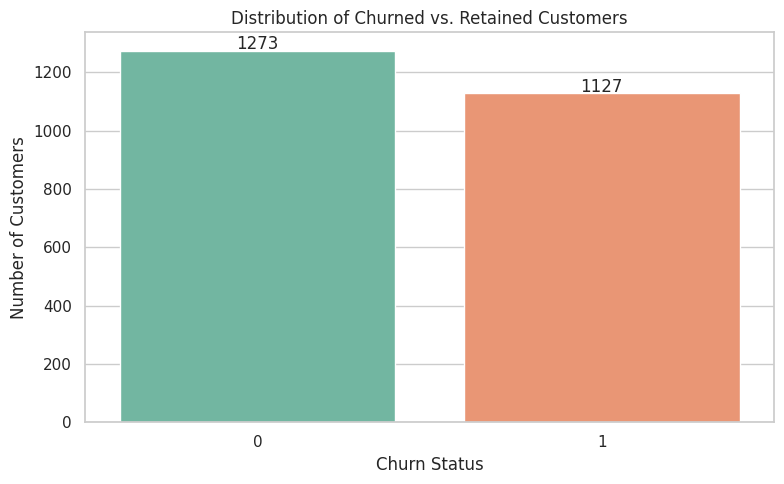

Overall Churn Rate: 46.96%


In [15]:
# Cell 4
churn_col = [col for col in churn_labels.columns if col not in ['customer_id', 'snapshot_date']][0]
df_merged = pd.merge(customers, churn_labels[['customer_id', churn_col]], on='customer_id', how='inner')
order_metrics = orders.groupby('customer_id').agg(
    total_orders=('order_id', 'count'),
    total_spend=('gross_amount', 'sum'),
    avg_discount=('discount_pct', 'mean'),
    total_returns=('returned', 'sum')
).reset_index()
df_master = pd.merge(df_merged, order_metrics, on='customer_id', how='left')
df_master.fillna({'total_orders': 0, 'total_spend': 0, 'avg_discount': 0, 'total_returns': 0}, inplace=True)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_master, x=churn_col, hue=churn_col, palette='Set2', legend=False)
plt.title('Distribution of Churned vs. Retained Customers')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()
churn_rate = (pd.to_numeric(df_master[churn_col], errors='coerce').sum() / len(df_master)) * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

/tmp/ipykernel_3659/3305511494.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x=churn_col, y='total_spend', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_3659/3305511494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_master, x=churn_col, y='total_returns', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_3659/3305511494.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_master, x=churn_col, y='total_tickets', ax=axes[0, 2], palette='Set2')
/tmp/ipykernel_3659/3305511494.py:14: FutureWarning: 

Passin

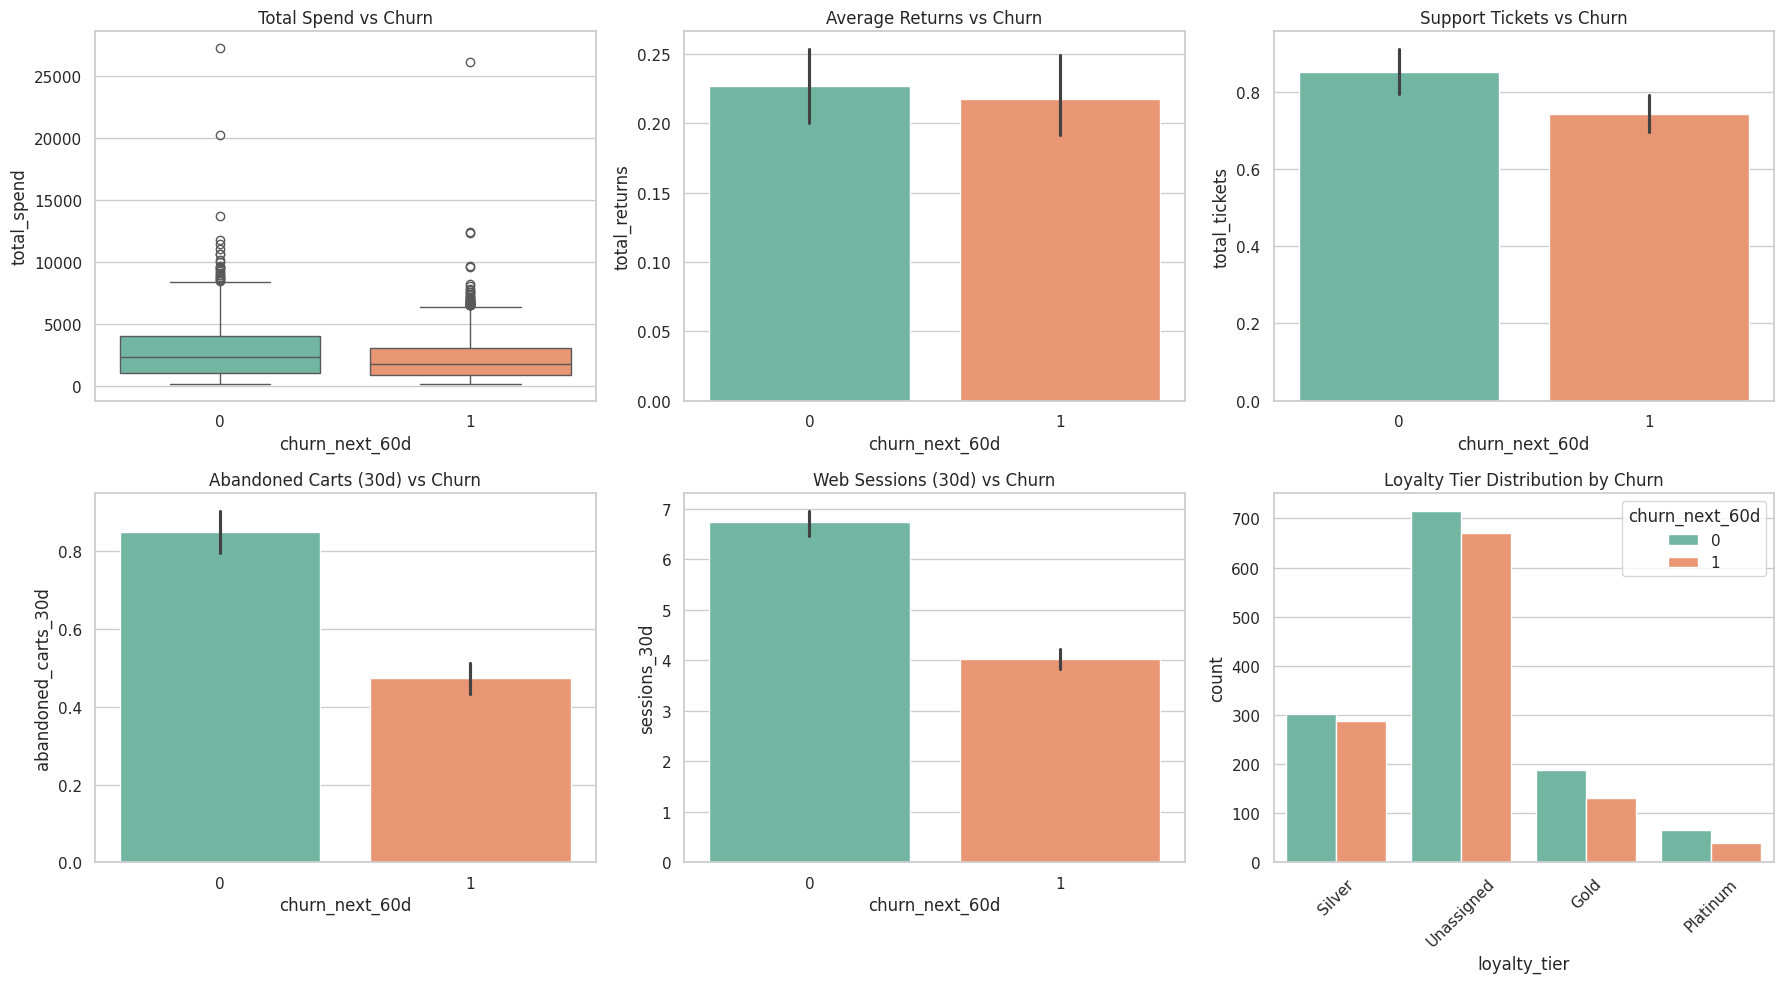

In [16]:
# Cell 5
support_metrics = support.groupby('customer_id').agg(total_tickets=('ticket_id', 'count')).reset_index()
df_master = pd.merge(df_master, support_metrics, on='customer_id', how='left')
df_master['total_tickets'] = df_master['total_tickets'].fillna(0)
df_master = pd.merge(df_master, web_events, on='customer_id', how='left')
df_master['loyalty_tier'] = df_master['loyalty_tier'].fillna('Unassigned')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.boxplot(data=df_master, x=churn_col, y='total_spend', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Total Spend vs Churn')
sns.barplot(data=df_master, x=churn_col, y='total_returns', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Average Returns vs Churn')
sns.barplot(data=df_master, x=churn_col, y='total_tickets', ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Support Tickets vs Churn')
sns.barplot(data=df_master, x=churn_col, y='abandoned_carts_30d', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Abandoned Carts (30d) vs Churn')
sns.barplot(data=df_master, x=churn_col, y='sessions_30d', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Web Sessions (30d) vs Churn')
sns.countplot(data=df_master, x='loyalty_tier', hue=churn_col, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Loyalty Tier Distribution by Churn')
axes[1, 2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()